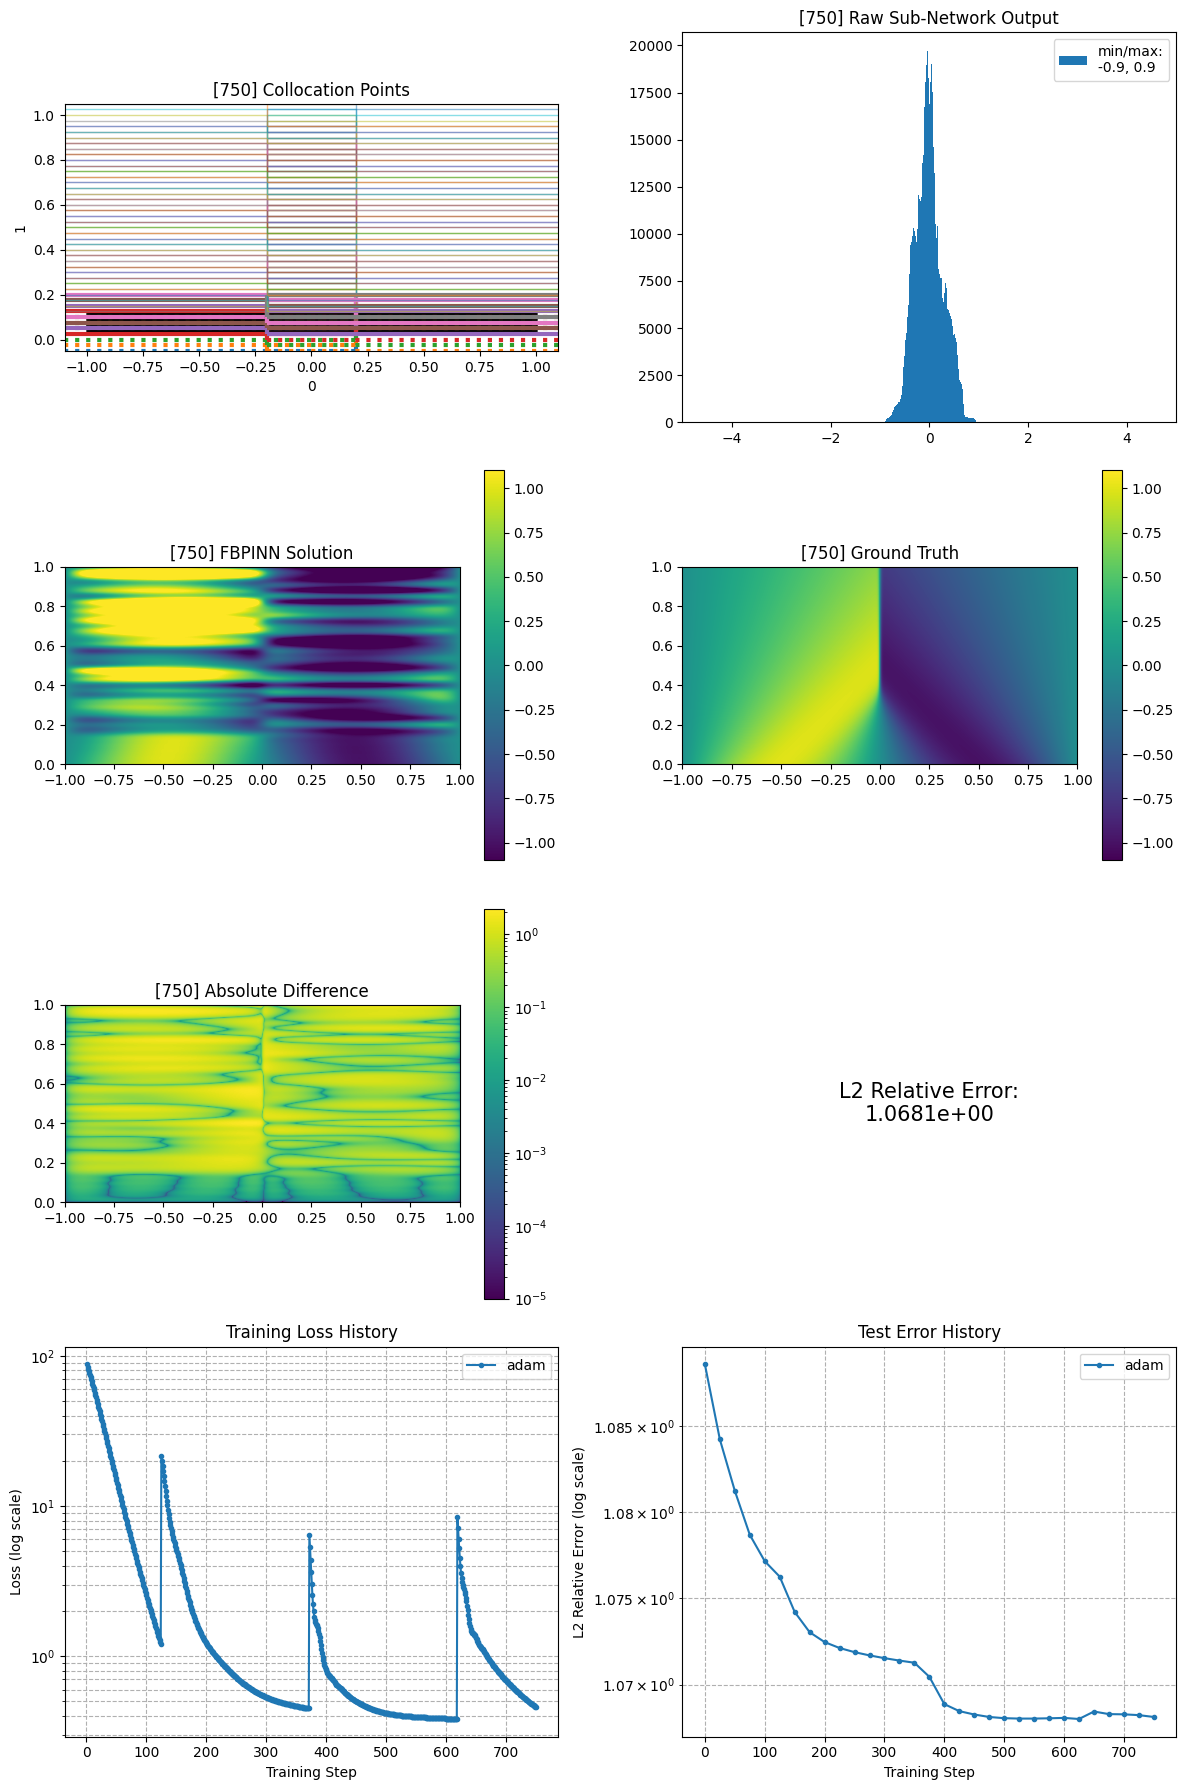

[INFO] 2025-07-01 04:31:56 - [i: 865/10000] Updating active inputs..
[INFO] 2025-07-01 04:31:56 - [i: 865/10000] Average number of points/dimension in active subdomains: 89.34
[INFO] 2025-07-01 04:32:00 - [i: 865/10000] Updating active inputs done (3.98 s)
[INFO] 2025-07-01 04:32:00 - [i: 865/10000] Initialising new state.
[INFO] 2025-07-01 04:32:00 - [i: 865/10000] Compiling update step..
[INFO] 2025-07-01 04:32:00 - x_batch
[INFO] 2025-07-01 04:32:00 - (13312, 2), float32, JVPTracer
[INFO] 2025-07-01 04:32:00 - x_take
[INFO] 2025-07-01 04:32:00 - (63856, 2), float32, JVPTracer
[INFO] 2025-07-01 04:32:00 - x_batch
[INFO] 2025-07-01 04:32:00 - (13312, 2), float32, JVPTracer
[INFO] 2025-07-01 04:32:00 - x_take
[INFO] 2025-07-01 04:32:00 - (63856, 2), float32, JVPTracer
[INFO] 2025-07-01 04:32:04 - [i: 865/10000] Compiling done (4.08 s)


KeyboardInterrupt: 

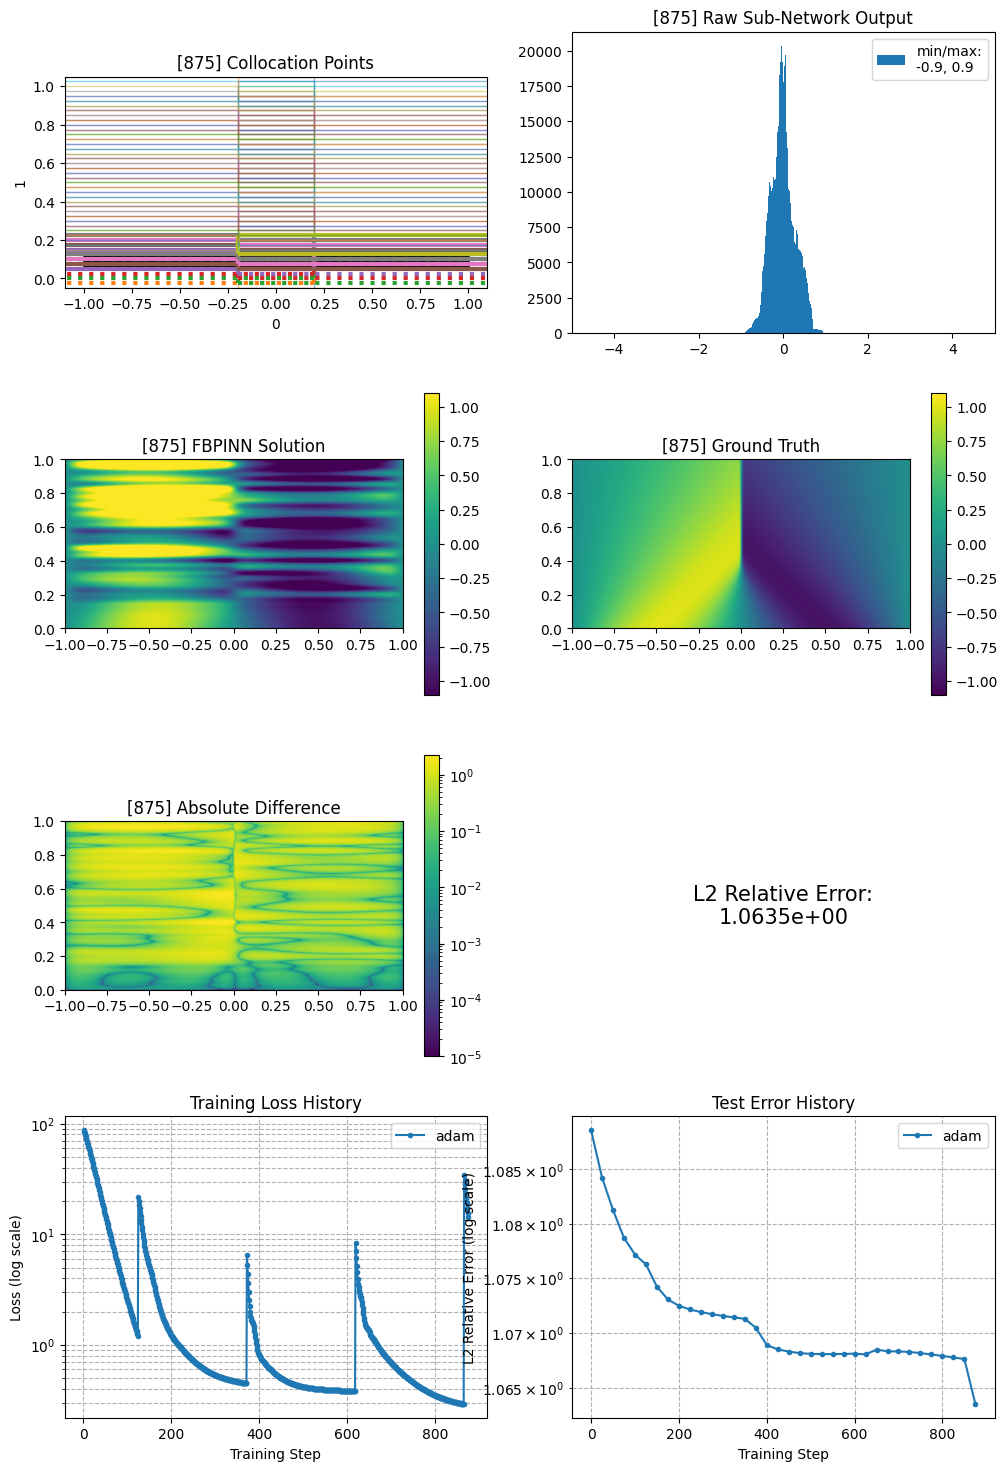

In [1]:
import numpy as np

from fbpinns.domains import RectangularDomainND
from fbpinns.problems import BurgersEquation2D
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.networks import FCN
from fbpinns.schedulers import LineSchedulerRectangularND
from fbpinns.constants import Constants, get_subdomain_ws
from fbpinns.trainers import FBPINNTrainer

import optax

from fbpinns.optimisers import adaptive_newton_method

subdomain_xs=[np.array([-0.5,0.5]), np.linspace(0,1,41)]
subdomain_ws=[np.array([1.4, 1.4]), np.array([0.1,] * len(subdomain_xs[1]))]

c = Constants(
    domain=RectangularDomainND,
    domain_init_kwargs = dict(
        xmin=np.array([-1,0.]),
        xmax=np.array([1.,1.])
        ),
    problem=BurgersEquation2D,
    problem_init_kwargs = dict(),
    decomposition=RectangularDecompositionND,
    decomposition_init_kwargs=dict(
        subdomain_xs=subdomain_xs,
        subdomain_ws=subdomain_ws,
        unnorm=(0.,3.),
    ),
    network=FCN,
    network_init_kwargs = dict(
        layer_sizes = (2, 8, 1),
    ),
    scheduler = LineSchedulerRectangularND,
    scheduler_kwargs = dict(
        point=[0.], iaxis=0,
    ),
    
    # sampler="sobol",
    
    ns=((512,256),),
    n_test=(512,256),
    clear_output=True,
    
    test_freq=1000 / 40,
    
    optimiser_schedule=[
        (optax.adam, 10000, dict(
            learning_rate=0.001,
        )),
    ],
)

run = FBPINNTrainer(c)
all_params = run.train()